# **First look at data**

## INFO 442  Group 5  Shuyang Zhang 320230942711

### **1. Profile from scratch. You've been handed this file with no documentation. Using only head(), shape, and info(), write a 3-bullet "data dictionary": (a) how many records there are, (b) which columns are measurements vs. labels, and (c) which columns you suspect are missing data — guessing from info() before you run any isnull count. Then verify your missing-data guess with df.isnull().sum().**

In [15]:
import pandas as pd
import seaborn as sns

df = pd.read_csv("penguins.csv")
print("Shape:", df.shape)
df.head()
df.info()
df.isnull().sum()

Shape: (344, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

**Answer:**

There are 344 records in the dataset.

Measurement columns: bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g.
Label columns: species, island, sex.

Based on the info() output, the Non-Null Count shows:

bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g have 342 non-null values (2 missing)

sex has 333 non-null values (11 missing)

My missing-data guess before running isnull().sum() was:

Numerical columns: 2 missing values each

sex column: 11 missing values

Verification: Running df.isnull().sum() confirmed exactly these numbers.

### **2. Don't trust head alone. Run df.head(), df.tail(), and df.sample(5). Why can head() give a misleading first impression of a dataset? (Think about how real files are often sorted.) Name one thing visible in tail or sample that head hides.**

In [24]:
df.head()
df.tail()
df.sample(5, random_state=42)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
194,Chinstrap,Dream,50.9,19.1,196.0,3550.0,MALE
157,Chinstrap,Dream,45.2,17.8,198.0,3950.0,FEMALE
225,Gentoo,Biscoe,46.5,13.5,210.0,4550.0,FEMALE
208,Chinstrap,Dream,45.2,16.6,191.0,3250.0,FEMALE
318,Gentoo,Biscoe,48.4,14.4,203.0,4625.0,FEMALE


**Answer:**

head() can give a misleading first impression because it only shows the first few rows of the dataset. If the file is sorted in some order, the first rows may not represent the full diversity of the data.

From the sample output above,we can see that head() might only show Adelie penguins if the data is sorted by species. The sample() output shows Chinstrap and Gentoo penguins, which head() could completely miss.One thing visible in tail() or sample() that head() hides: there are other species besides Adelie.

### **3. Read shape from the summary. From describe(), compare the mean and the median of body_mass_g. Are they close, and what does that say about the distribution's shape? Then find one column whose min or max looks biologically implausible, and say how you would check whether it's a real value or an error.**

In [31]:
df.describe()
mean_mass = df["body_mass_g"].mean()
median_mass = df["body_mass_g"].median()
print(f"Mean: {mean_mass:.1f}, Median: {median_mass:.1f}")
print(f"Difference: {abs(mean_mass - median_mass):.1f}")

Mean: 4201.8, Median: 4050.0
Difference: 151.8


In [35]:
for col in ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]:
    print(f"{col}: min = {df[col].min()}, max = {df[col].max()}")

max_flipper = df[df["flipper_length_mm"] == df["flipper_length_mm"].max()]
print(max_flipper)

bill_length_mm: min = 32.1, max = 59.6
bill_depth_mm: min = 13.1, max = 21.5
flipper_length_mm: min = 172.0, max = 231.0
body_mass_g: min = 2700.0, max = 6300.0
    species  island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
283  Gentoo  Biscoe            54.3           15.7              231.0   

     body_mass_g   sex  
283       5650.0  MALE  


**Answer:**

The mean (4201.8 g) and median (4050.0 g) are not very close - the difference is about 152 g. The mean is larger than the median, which indicates the distribution is right-skewed (has a longer tail toward higher values).

Among all numeric columns, all min/max values are biologically plausible for penguin measurements:

Bill length (32.1-59.6 mm) - reasonable range for penguin species

Bill depth (13.1-21.5 mm) - reasonable

Flipper length (172-231 mm) - reasonable

Body mass (2700-6300 g) - reasonable

### **4. Counts have consequences. Count the penguins of each species. The groups are uneven — is that a problem? Describe one later analysis where unequal group sizes could quietly mislead you.**

In [42]:
df["species"].value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

**Answer:**

Yes, in certain analyses.

When comparing mean body mass across species using ANOVA or t-tests, Chinstrap has the smallest sample. This gives it the largest standard error, meaning its confidence interval is widest. A true difference involving Chinstrap might fail to reach statistical significance, not because there's no difference, but because we don't have enough Chinstrap penguins to detect it.

### **5. Missing data, and what it would cost. Which columns have missing values, and how many each? Which is missing the most? Now the decision that matters: if you simply dropped every row with any missing value, how many penguins would you lose — and is that loss spread evenly across species? (This is the question that decides whether dropping rows is safe.)**



In [46]:
print(df.isnull().sum())

df_dropped = df.dropna()
print(f"Lost: {len(df) - len(df_dropped)} penguins")

missing_rows = df[df.isnull().any(axis=1)]
print(missing_rows['species'].value_counts())

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64
Lost: 11 penguins
species
Adelie    6
Gentoo    5
Name: count, dtype: int64


**Answer:**

The columns with missing values are bill_length_mm, bill_depth_mm, flipper_length_mm, and body_mass_g, each missing 2 values, and sex, which is missing 11 values. The sex column has the most missing values. If you simply dropped every row with any missing value, you would lose 11 penguins in total. However, this loss is not spread evenly across species — Adelie lost 6 rows, Gentoo lost 5 rows, and Chinstrap lost 0 rows. Therefore, dropping rows is not safe because the missing data is biased toward Adelie and Gentoo, which could skew any species-level analysis.

### **6. Where do the species live? Which species was seen on all three islands, and which two each live on only one?**

In [50]:
pd.crosstab(df["species"], df["island"])

island,Biscoe,Dream,Torgersen
species,,,
Adelie,44,56,52
Chinstrap,0,68,0
Gentoo,124,0,0


**Answer:**

Adelie is the only species that was seen on all three islands (Biscoe, Dream, and Torgersen). Gentoo lives only on Biscoe, and Chinstrap lives only on Dream.

### **7. Make a quick histogram of body_mass_g. Does it look like one smooth hump, or can you already see signs of hidden groups? Write one sentence describing what you see.**

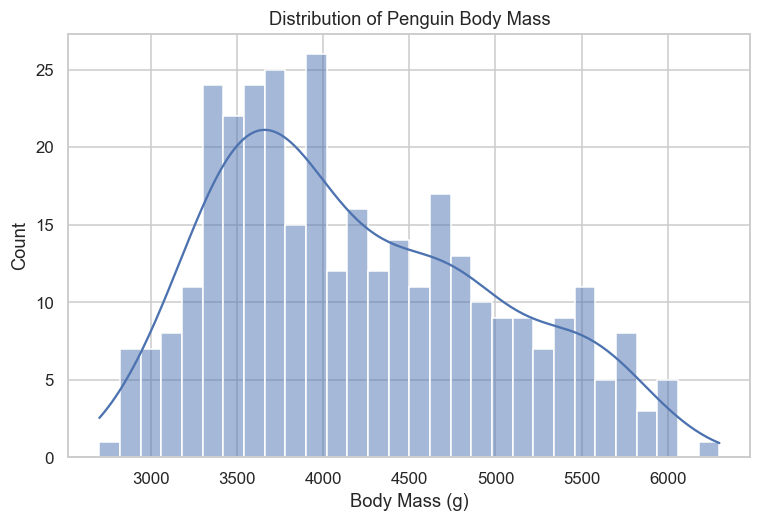

In [54]:
plt.figure(figsize=(8, 5))
sns.histplot(df["body_mass_g"].dropna(), bins=30, kde=True)
plt.title("Distribution of Penguin Body Mass")
plt.xlabel("Body Mass (g)")
plt.ylabel("Count")
plt.show()

**Answer:**

The histogram does not look like one smooth hump; it shows multiple peaks, indicating the presence of hidden groups (different penguin species) within the data